# Start by reading in a physics state:

In [1]:
import xarray as xr
import ndsl.dsl.gt4py_utils as gt_utils
from ndsl import GridSizer, Quantity, QuantityFactory, TileCommunicator, TilePartitioner, NullComm, SubtileGridSizer
import ndsl.constants as constants

from pySHiELD.radiation.radiation_state import RadiationState
from pySHiELD._config import PHYSICS_PACKAGES
import numpy as np
import matplotlib.pyplot as plt

2025-07-02 16:07:00|INFO|rank 0|ndsl.logging:Constant selected: ConstantVersions.UFS


In [2]:
ds = xr.open_dataset("RESTART/restart_physics_state_0.nc")
ds2 = xr.open_dataset("RESTART/restart_dycore_state_0.nc")

In [3]:
schemes = PHYSICS_PACKAGES

In [4]:
nx_tile=20
ny_tile=20
nz=79
n_halo=3

In [5]:
rank = 0

comm = NullComm(rank, 1)
communicator = TileCommunicator.from_layout(comm=comm, layout=(1,1))

sizer = SubtileGridSizer.from_tile_params(
    nx_tile=nx_tile,
    ny_tile=ny_tile,
    nz=nz,
    n_halo=n_halo,
    extra_dim_lengths={},
    layout=(1,1),
    tile_partitioner=communicator.partitioner.tile,
    tile_rank=communicator.tile.rank,
)
quantity_factory = QuantityFactory.from_backend(
    sizer, backend="numpy"
)

In [6]:
state = RadiationState.init_zeros(quantity_factory, np)

In [7]:
pkz = ds2.pkz.values
pe = ds2.pe.values
pk = ds2.pk.values

In [8]:
p_lay = pkz[:,:,::-1]** (1./constants.KAPPA)

# Now we need certain things from the physics state:
 - level pressure in Pa
 - layer pressure in Pa
 - level temperature in K
 - layer temperature in K
 - surface temperature in K
 - water vapor mixing ratio in kg/kg
 - ozone mixing ratio in kg/kg

In [9]:
print(ds.variables)

Frozen({'qvapor': <xarray.Variable (x_qvapor: 27, y_qvapor: 27, z_qvapor: 80)> Size: 467kB
[58320 values with dtype=float64]
Attributes:
    long_name:  specific_humidity
    units:      kg/kg, 'qliquid': <xarray.Variable (x_qliquid: 27, y_qliquid: 27, z_qliquid: 80)> Size: 467kB
[58320 values with dtype=float64]
Attributes:
    long_name:  cloud_water_mixing_ratio
    units:      kg/kg, 'qice': <xarray.Variable (x_qice: 27, y_qice: 27, z_qice: 80)> Size: 467kB
[58320 values with dtype=float64]
Attributes:
    long_name:  cloud_ice_mixing_ratio
    units:      kg/kg, 'qrain': <xarray.Variable (x_qrain: 27, y_qrain: 27, z_qrain: 80)> Size: 467kB
[58320 values with dtype=float64]
Attributes:
    long_name:  rain_mixing_ratio
    units:      kg/kg, 'qsnow': <xarray.Variable (x_qsnow: 27, y_qsnow: 27, z_qsnow: 80)> Size: 467kB
[58320 values with dtype=float64]
Attributes:
    long_name:  snow_mixing_ratio
    units:      kg/kg, 'qgraupel': <xarray.Variable (x_qgraupel: 27, y_qgraupel: 27, 

In [10]:
ds.delp.shape

(27, 27, 80)

In [11]:
prsi = ds.prsi.values[3:-4,3:-4,::-1] # level pressure
pt = ds.pt.values[3:-4,3:-4,-2::-1] # Layer temperature
delp = ds.delp.values[3:-4,3:-4,-2::-1]
delz = -1.* ds.delz.values[3:-4,3:-4,-2::-1]
dz = -1.* ds.dz.values[3:-4,3:-4,-2::-1]
qvap = ds.qvapor.values[3:-4,3:-4,-2::-1]
qliq = ds.qliquid.values[3:-4,3:-4,-2::-1]
qice = ds.qice.values[3:-4,3:-4,-2::-1]
qcld = ds.qcld.values[3:-4,3:-4,-2::-1]
phii = ds.phii.values[3:-4,3:-4,::-1]

Derive layer mean pressure from interface pressure

In [12]:
prsl = (prsi[:,:,1:] - prsi[:,:,:-1]) / np.log(prsi[:,:,1:] / prsi[:,:,:-1])
prsl

array([[[99811.11444245, 99419.49467629, 98937.69113034, ...,
          1245.19882957,   830.08703879,   451.37975146],
        [99857.98743327, 99466.15895168, 98984.07452286, ...,
          1245.19882957,   830.08703879,   451.37975146],
        [99844.29369399, 99452.5261877 , 98970.52381758, ...,
          1245.19882957,   830.08703879,   451.37975146],
        ...,
        [99856.5796876 , 99464.75747439, 98982.68148139, ...,
          1245.19882957,   830.08703879,   451.37975146],
        [99869.86206999, 99477.98071317, 98995.82512649, ...,
          1245.19882957,   830.08703879,   451.37975146],
        [99820.72241658, 99429.05986815, 98947.19874714, ...,
          1245.19882957,   830.08703879,   451.37975146]],

       [[99785.68907724, 99394.1825248 , 98912.53133844, ...,
          1245.19882957,   830.08703879,   451.37975146],
        [99829.68613929, 99437.98367732, 98956.06884188, ...,
          1245.19882957,   830.08703879,   451.37975146],
        [99801.67355555, 

Or from delp delz T and Q

In [13]:
# prsl2 = delp / (phii[:,:,1:] - phii[:,:,:-1]) * constants.RDGAS * pt * (1 + constants.ZVIR * qvap)
# prsl2

Get the level (interface) temperatures too

In [14]:
ptlev = np.zeros_like(prsi)
ptlev[:,:,1:-1] = pt[:,:,:-1] + (pt[:,:,1:] - pt[:,:,:-1]) * (np.log(prsi[:,:,1:-1]) - np.log(prsl[:,:,:-1])) / (np.log(prsl[:,:,1:]) - np.log(prsl[:,:,:-1]))
ptlev[:,:,-1] = pt[:,:,-1]
ptlev[:,:,0] = pt[:,:,0]

In [15]:
qo3mr = ds.qo3mr.values
tskin = ptlev[:,:,-1]

And populate the state

In [16]:
type(state.prsi)

numpy.ndarray

In [17]:
xds = state.to_rterrtmgp_xr()

In [22]:
mu = np.sin(np.arange(400) * np.pi / 400.) - 0.3

In [23]:
# xds.mu0.data[:] = 0.86
xds.mu0.data[:] = mu
xds.albedo.data[:] = 0.06
xds.sfc_emis.data[:] = 0.98

In [24]:
xds.prsi.data = prsi.reshape(-1, 80)
xds.prsl.data = prsl.reshape(-1, 79)
xds.tlyr.data = pt.reshape(-1, 79)
xds.tlvl.data = ptlev.reshape(-1, 80)
xds.tsfc.data = tskin.reshape(-1)
xds.qvapor.data = qvap.reshape(-1, 79)
xds.qliquid.data = qliq.reshape(-1, 79)
xds.qice.data = qice.reshape(-1, 79)
# xds.qsnow.data = qice
# xds.qrain.data = qice
# xds.qgraupel.data = qice
xds

<xarray.Dataset> Size: 3MB
Dimensions:   (column: 400, level: 80, layer: 79)
Dimensions without coordinates: column, level, layer
Data variables: (12/16)
    prsi      (column, level) float64 256kB 9.998e+04 9.964e+04 ... 646.7 300.0
    prsl      (column, layer) float64 253kB 9.981e+04 9.942e+04 ... 830.1 451.4
    tlyr      (column, layer) float64 253kB 293.0 292.9 292.7 ... 266.4 267.6
    tlvl      (column, level) float64 256kB 293.0 292.9 292.8 ... 266.9 267.6
    tsfc      (column) float64 3kB 267.7 267.6 267.5 267.5 ... 267.5 267.6 267.6
    mu0       (column) float64 3kB -0.3 -0.2921 -0.2843 ... -0.2843 -0.2921
    ...        ...
    qice      (column, layer) float64 253kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    qo3mr     (column, layer) float64 253kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    qcld      (column, layer) float64 253kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    clwp      (column, layer) float64 253kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    cip       (column, layer) float64 253kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    clwr      (column, layer) float64 253kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

We need some other aerosols:

In [25]:
gas_values = {
    "co2": 348e-6,
    "ch4": 1650e-9,
    "n2o": 306e-9,
    "n2": 0.7808,
    "o2": 0.2095,
    "co": 0.0,
}
for gas_name, value in gas_values.items():
    xds[gas_name] = value
xds

<xarray.Dataset> Size: 3MB
Dimensions:   (column: 400, level: 80, layer: 79)
Dimensions without coordinates: column, level, layer
Data variables: (12/22)
    prsi      (column, level) float64 256kB 9.998e+04 9.964e+04 ... 646.7 300.0
    prsl      (column, layer) float64 253kB 9.981e+04 9.942e+04 ... 830.1 451.4
    tlyr      (column, layer) float64 253kB 293.0 292.9 292.7 ... 266.4 267.6
    tlvl      (column, level) float64 256kB 293.0 292.9 292.8 ... 266.9 267.6
    tsfc      (column) float64 3kB 267.7 267.6 267.5 267.5 ... 267.5 267.6 267.6
    mu0       (column) float64 3kB -0.3 -0.2921 -0.2843 ... -0.2843 -0.2921
    ...        ...
    co2       float64 8B 0.000348
    ch4       float64 8B 1.65e-06
    n2o       float64 8B 3.06e-07
    n2        float64 8B 0.7808
    o2        float64 8B 0.2095
    co        float64 8B 0.0

# Time to get the radiation going

In [26]:
from pyrte_rrtmgp import rrtmgp_cloud_optics, rrtmgp_gas_optics
from pyrte_rrtmgp.data_types import (
    CloudOpticsFiles,
    GasOpticsFiles,
    OpticsProblemTypes,
)
from pyrte_rrtmgp.rte_solver import rte_solve
from pyrte_rrtmgp.examples import (
    compute_RCE_clouds,
    compute_RCE_profiles,
    ALLSKY_EXAMPLES,
    load_example_file,
)
from pyrte_rrtmgp.data_validation import AtmosphericMapping
from pyrte_rrtmgp.config import (
    DEFAULT_DIM_MAPPING,
    DEFAULT_VAR_MAPPING,
)

In [27]:
cloud_optics_lw = rrtmgp_cloud_optics.load_cloud_optics(
    cloud_optics_file=CloudOpticsFiles.LW_BND
)
gas_optics_lw = rrtmgp_gas_optics.load_gas_optics(
    gas_optics_file=GasOpticsFiles.LW_G256
)

cloud_optics_sw = rrtmgp_cloud_optics.load_cloud_optics(
    cloud_optics_file=CloudOpticsFiles.SW_BND
)
gas_optics_sw = rrtmgp_gas_optics.load_gas_optics(
    gas_optics_file=GasOpticsFiles.SW_G224
)

In [28]:
gas_mapping = {
    "h2o": "qvapor",
    "o3": "qo3mr",
    'co':'co',
    'n2o': 'n2o',
    'o2': 'o2',
    'co2': 'co2',
    'n2': 'n2'
}
var_mapping = {
    "pres_layer": "prsl",
    "pres_level": "prsi",
    "temp_layer": "tlyr",
    "temp_level": "tlvl",
    "surface_temperature": "tsfc",
    "solar_zenith_angle": "solar_zenith_angle",
    "surface_albedo": "surface_albedo",
    "surface_albedo_direct": "surface_albedo_direct",
    "surface_albedo_diffuse": "surface_albedo_diffuse",
    "surface_emissivity": "surface_emissivity",
    "surface_emissivity_jacobian": "surface_emissivity_jacobian",   
}
atm_map = AtmosphericMapping(dim_mapping=DEFAULT_DIM_MAPPING, var_mapping=var_mapping,)

## And compute some optics:

In [29]:
optical_props = gas_optics_lw.compute_gas_optics(
    xds, 
    problem_type=OpticsProblemTypes.ABSORPTION, 
    add_to_input=False,
    gas_name_map=gas_mapping,
    variable_mapping=atm_map,
)



In [30]:
optical_props

<xarray.Dataset> Size: 197MB
Dimensions:                  (column: 400, gpt: 256, layer: 79, level: 80,
                              bnd: 16, pair: 2)
Coordinates:
  * column                   (column) int64 3kB 0 1 2 3 4 ... 396 397 398 399
  * gpt                      (gpt) int64 2kB 0 1 2 3 4 5 ... 251 252 253 254 255
Dimensions without coordinates: layer, level, bnd, pair
Data variables:
    surface_source           (gpt, column) float64 819kB 0.5601 ... 5.514e-07
    layer_source             (layer, gpt, column) float64 65MB 0.6438 ... 1.0...
    level_source             (level, gpt, column) float64 66MB 0.6438 ... 1.0...
    surface_source_jacobian  (gpt, column) float64 819kB 0.003278 ... 3.245e-08
    tau                      (layer, gpt, column) float64 65MB 1.783 ... 2.66...
    bnd_limits_gpt           (bnd, pair) int32 128B 1 16 17 32 ... 240 241 256
Attributes:
    problem_type:     Longwave absorption
    top_at_1:         False
    dataset_mapping:  {"dim_mapping": {"layer": "layer", "level": "level"}, "...

In [31]:
optical_props["surface_emissivity"] = xds["sfc_emis"]

In [32]:
clr_fluxes_lw = rte_solve(optical_props, add_to_input=False)
clr_fluxes_lw

<xarray.Dataset> Size: 515kB
Dimensions:       (column: 400, level: 80)
Coordinates:
  * column        (column) int64 3kB 0 1 2 3 4 5 6 ... 394 395 396 397 398 399
Dimensions without coordinates: level
Data variables:
    lw_flux_up    (column, level) float64 256kB 291.7 334.8 ... 262.9 263.6
    lw_flux_down  (column, level) float64 256kB 326.6 325.6 324.2 ... 15.83 0.0

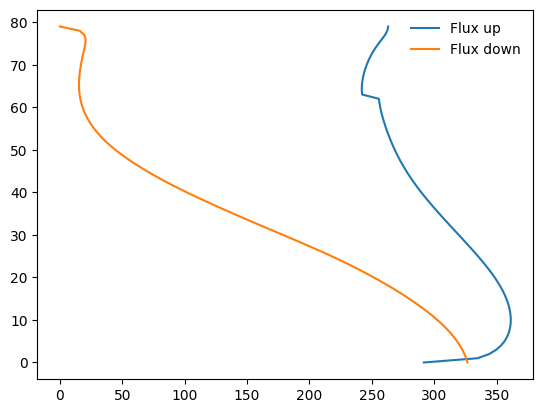

In [33]:
plt.plot(clr_fluxes_lw.lw_flux_up.isel(column=0),   clr_fluxes_lw.level, label="Flux up")
plt.plot(clr_fluxes_lw.lw_flux_down.isel(column=0), clr_fluxes_lw.level, label="Flux down")
plt.legend(frameon=False)

and the SW fluxes:

In [34]:
sw_optics = gas_optics_sw.compute_gas_optics(
    xds, 
    problem_type=OpticsProblemTypes.TWO_STREAM, 
    add_to_input=False,
    gas_name_map=gas_mapping,
    variable_mapping=atm_map,
)
sw_optics

<xarray.Dataset> Size: 171MB
Dimensions:         (column: 400, gpt: 224, layer: 79, bnd: 14, pair: 2)
Coordinates:
  * column          (column) int64 3kB 0 1 2 3 4 5 6 ... 394 395 396 397 398 399
Dimensions without coordinates: gpt, layer, bnd, pair
Data variables:
    toa_source      (column, gpt) float64 717kB 1.994 1.938 ... 0.001233
    tau             (layer, gpt, column) float64 57MB 0.001287 ... 0.1302
    ssa             (layer, gpt, column) float64 57MB 7.253e-05 ... 0.1821
    g               (layer, gpt, column) float64 57MB 0.0 0.0 0.0 ... 0.0 0.0
    bnd_limits_gpt  (bnd, pair) int32 112B 1 16 17 32 33 ... 192 193 208 209 224
Attributes:
    problem_type:     Shortwave 2-stream
    top_at_1:         False
    dataset_mapping:  {"dim_mapping": {"layer": "layer", "level": "level"}, "...

In [35]:
sw_optics["surface_albedo"] = xds["albedo"]
sw_optics["mu0"] = xds["mu0"]
fluxes_sw = rte_solve(sw_optics, add_to_input=False)

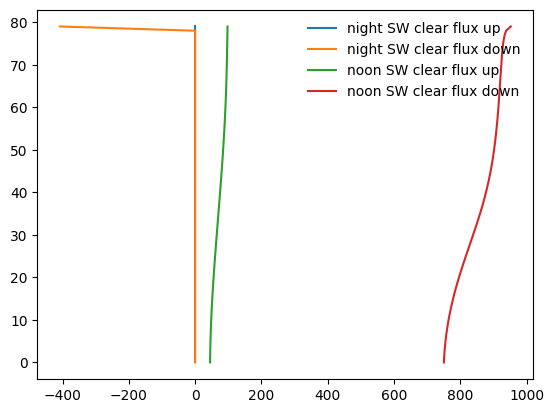

In [43]:
plt.plot(fluxes_sw.sw_flux_up.isel(column=0), fluxes_sw.level, label="night SW clear flux up")
plt.plot(fluxes_sw.sw_flux_down.isel(column=0), fluxes_sw.level, label="night SW clear flux down")
plt.plot(fluxes_sw.sw_flux_up.isel(column=200), fluxes_sw.level, label="noon SW clear flux up")
plt.plot(fluxes_sw.sw_flux_down.isel(column=200), fluxes_sw.level, label="noon SW clear flux down")
plt.legend(frameon=False)

In [44]:
fluxes_sw.sw_flux_down.isel(column=0)

<xarray.DataArray 'sw_flux_down' (level: 80)> Size: 640B
array([ 0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000, -1.42452702e-302,
       -1.68603776e-253, -8.02706916e-208, -2.69714616e-164,
       -9.80647362e-123, -1.09476635e-083, -3.17141901e-046,
       -3.99432327e-016, -4.08257302e+002])
Coordinates:
    column   int64 8B 0
Dimensions without coordinates: level

In [52]:
fluxes_sw.sw_flux_down.data[mu > 0.0][:,:-1]

array([[ 0.71499729,  0.71569689,  0.71658567, ...,  1.65352235,
         1.73254107,  1.84511152],
       [ 4.18695022,  4.1932138 ,  4.20119755, ..., 11.16623947,
        11.39154216, 11.64728719],
       [ 7.95124629,  7.9665251 ,  7.98601214, ..., 20.92018869,
        21.19664473, 21.50389819],
       ...,
       [ 8.15087082,  8.1662603 ,  8.18588287, ..., 20.92377697,
        21.19930177, 21.50558166],
       [ 4.16106301,  4.16741578,  4.17551712, ..., 11.1652362 ,
        11.39079243, 11.64681736],
       [ 0.70597661,  0.70669188,  0.70760087, ...,  1.65253489,
         1.73180736,  1.84464338]])

In [54]:
fluxes_sw

<xarray.Dataset> Size: 771kB
Dimensions:       (column: 400, level: 80)
Coordinates:
  * column        (column) int64 3kB 0 1 2 3 4 5 6 ... 394 395 396 397 398 399
Dimensions without coordinates: level
Data variables:
    sw_flux_up    (column, level) float64 256kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sw_flux_down  (column, level) float64 256kB 0.0 0.0 ... -2.686e-16 -397.6
    sw_flux_dir   (column, level) float64 256kB 0.0 0.0 ... -2.686e-16 -397.6